This notebook explores the effect of wind on the antennae of the fly. Here, each antenna is connected to the head with a ball joint. The wind applies a force on the antenna (for details, see [the MuJoCo documentation on inertia-based model offluid dynamics](https://mujoco.readthedocs.io/en/stable/computation/fluid.html#inertia-model)), which causes it to deflect. When the wind stops, the antenna will return to its original position due to the stiffness of the joint. We will simulate this process and visualize the antenna deflection over time.

In [1]:
import cv2
from miniproject.simulation import create_fly
from flygym.compose import ActuatorType
from flygym.compose.world import FlatGroundWorld
from flygym.utils.math import Rotation3D
from flygym import Simulation
import numpy as np

In [2]:
fly = create_fly()

cam_kwargs_front = {
    "name": "front_cam",
    "mode": "fixed",
    "pos_offset": (2.5, 0, 1.25),
    "rotation": Rotation3D("euler", (np.pi / 2, 0, np.pi / 2)),
    "fovy": 40,
}

cam_kwargs_top = {
    "name": "top_cam",
    "mode": "fixed",
    "pos_offset": (1, 0, 2.5),
    "rotation": Rotation3D("euler", (0, 0, -np.pi / 2)),
    "fovy": 40,
}

cam_kwargs_right = {
    "name": "right_cam",
    "mode": "fixed",
    "pos_offset": (1, -1, 1.25),
    "rotation": Rotation3D("euler", (np.pi / 2, 0, 0)),
    "fovy": 40,
}
cam_front = fly.add_tracking_camera(**cam_kwargs_front)
cam_top = fly.add_tracking_camera(**cam_kwargs_top)
cam_right = fly.add_tracking_camera(**cam_kwargs_right)

In [3]:
world = FlatGroundWorld()
checker = world.mjcf_root.find("texture", "checker")
checker.rgb1 = (1, 1, 1)
checker.rgb2 = (1, 1, 1)
world.add_fly(
    fly, spawn_position=(0, 0, 0.1), spawn_rotation=Rotation3D("quat", (1, 0, 0, 0))
)

In [4]:
from scipy.spatial.transform import Rotation
wind_magnitude = 60000

sim = Simulation(world)
sim.set_renderer([cam_front, cam_top, cam_right], camera_res=(256, 256))
sim.reset()

for i in range(2000):
    sim.step()

sim.set_actuator_inputs(fly.name, ActuatorType.ADHESION, np.array([1.0] * 6))

for i in range(8):
    angle_deg = 45 * i
    sim.set_wind(wind_magnitude, angle_deg)

    for _ in range(2000):
        sim.step()
        if sim.render_as_needed():
            for frames in sim.renderer.frames.values():
                cv2.putText(
                    frames[-1],
                    f"Wind Angle: {round(angle_deg)} deg",
                    (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.7,
                    (0, 0, 0),
                    2,
                )

    antenna_data = sim.get_antenna_data(fly.name)
    quat_l = antenna_data['l']['qpos']  # [w, x, y, z]
    quat_r = antenna_data['r']['qpos']
    
    euler_l = Rotation.from_quat([quat_l[1], quat_l[2], quat_l[3], quat_l[0]]).as_euler('xyz', degrees=True)
    euler_r = Rotation.from_quat([quat_r[1], quat_r[2], quat_r[3], quat_r[0]]).as_euler('xyz', degrees=True)
    
    diff = euler_l - euler_r
    
    print(f"Wind angle: {angle_deg}°")
    print(f"  Left  euler: pitch={euler_l[0]:.2f}°, roll={euler_l[1]:.2f}°, yaw={euler_l[2]:.2f}°")
    print(f"  Right euler: pitch={euler_r[0]:.2f}°, roll={euler_r[1]:.2f}°, yaw={euler_r[2]:.2f}°")
    print(f"  L-R diff:    pitch={diff[0]:.2f}°, roll={diff[1]:.2f}°, yaw={diff[2]:.2f}°")
    print()

    sim.set_wind(0, 0)

    for _ in range(1000):
        sim.step()
        sim.render_as_needed()

sim.renderer.show_in_notebook()

Wind angle: 0°
  Left  euler: pitch=-8.16°, roll=-5.30°, yaw=0.69°
  Right euler: pitch=8.14°, roll=-5.29°, yaw=-0.69°
  L-R diff:    pitch=-16.30°, roll=-0.01°, yaw=1.38°

Wind angle: 45°
  Left  euler: pitch=1.70°, roll=-2.53°, yaw=1.72°
  Right euler: pitch=12.84°, roll=-5.58°, yaw=-1.42°
  L-R diff:    pitch=-11.14°, roll=3.05°, yaw=3.15°

Wind angle: 90°
  Left  euler: pitch=2.74°, roll=3.23°, yaw=1.19°
  Right euler: pitch=13.25°, roll=3.94°, yaw=1.35°
  L-R diff:    pitch=-10.52°, roll=-0.71°, yaw=-0.17°

Wind angle: 135°
  Left  euler: pitch=2.58°, roll=13.97°, yaw=-0.85°
  Right euler: pitch=13.10°, roll=9.38°, yaw=2.94°
  L-R diff:    pitch=-10.51°, roll=4.59°, yaw=-3.79°

Wind angle: 180°
  Left  euler: pitch=-2.81°, roll=13.15°, yaw=-1.15°
  Right euler: pitch=3.09°, roll=13.06°, yaw=1.20°
  L-R diff:    pitch=-5.91°, roll=0.08°, yaw=-2.35°

Wind angle: 225°
  Left  euler: pitch=-12.93°, roll=9.55°, yaw=-2.96°
  Right euler: pitch=-2.50°, roll=14.17°, yaw=1.07°
  L-R diff: 

nmf/front_cam This browser does not support the video tag.


nmf/top_cam This browser does not support the video tag.


nmf/right_cam This browser does not support the video tag.


We can retrieve the joint state (position in quaternion format, angular velocities and accelerations) and torques with `sim.get_antenna_data`:

In [5]:
sim.get_antenna_data(fly.name)

{'l': {'qpos': array([ 0.99784931, -0.06431949,  0.01159979,  0.00502095]),
  'qvel': array([ 0.45647668,  0.56760959, -0.01446059]),
  'qacc': array([-16.00091514, -22.15418647,   4.73208243]),
  'qfrc_passive': array([ 8.30671971e-04, -7.99964665e-04, -8.61428296e-05])},
 'r': {'qpos': array([ 0.99932577,  0.03106377,  0.01879454, -0.00546067]),
  'qvel': array([0.44984093, 0.37956173, 0.09994724]),
  'qacc': array([-13.28875976, -13.45844387,  -3.48936195]),
  'qfrc_passive': array([-1.07141939e-03, -7.55671397e-04,  9.29898148e-06])}}

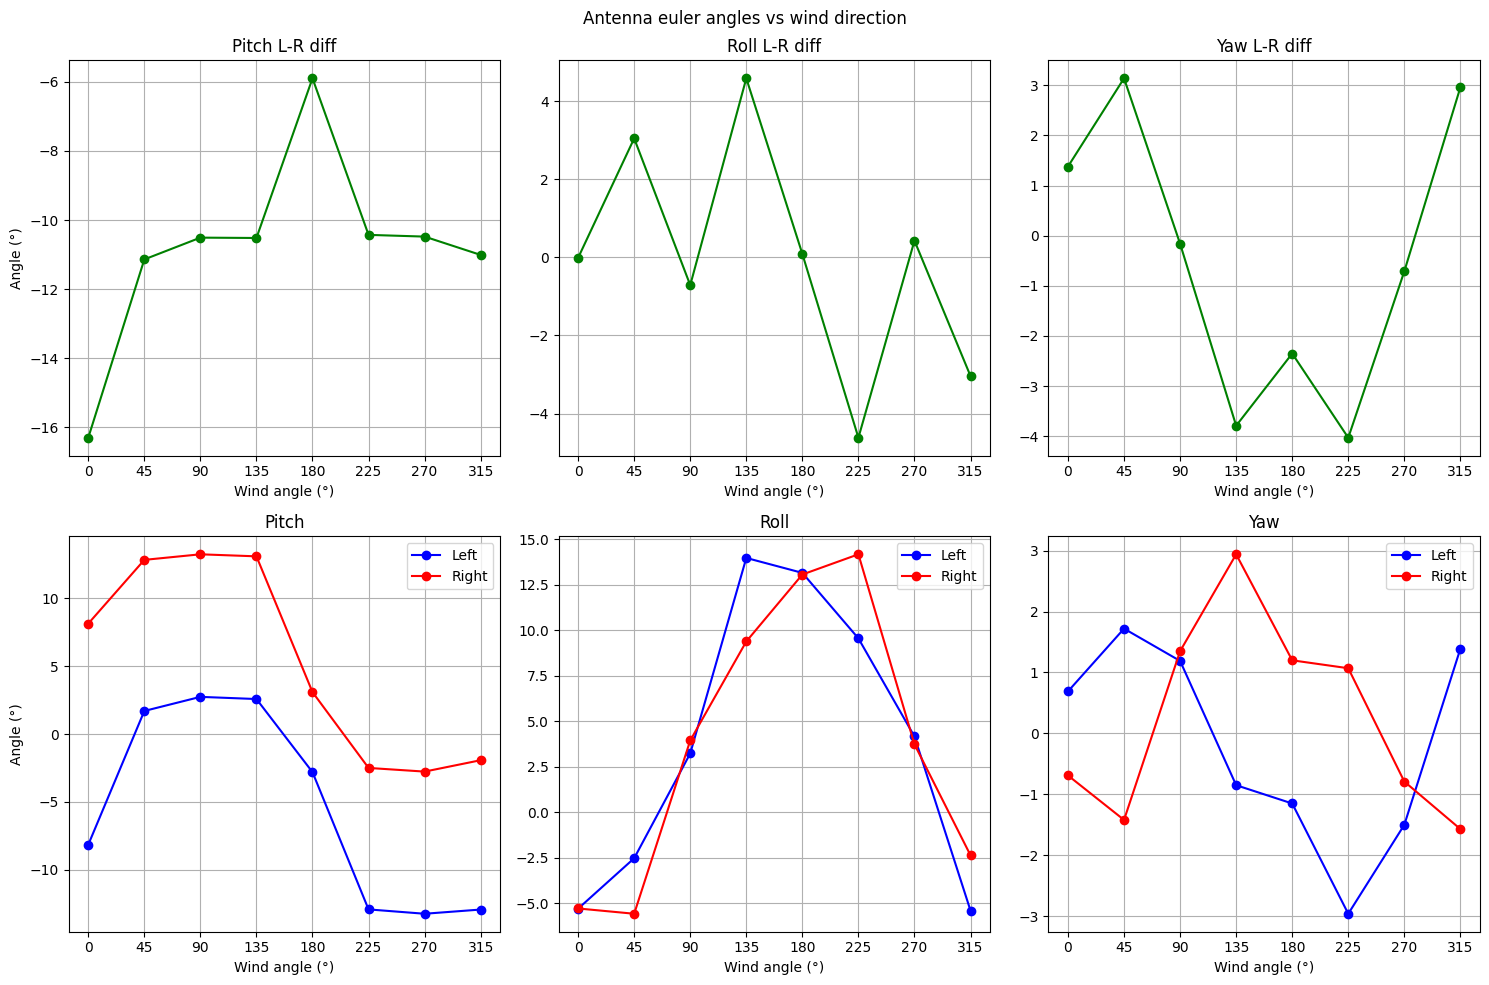

In [6]:
import numpy as np
import matplotlib.pyplot as plt

angles = [0, 45, 90, 135, 180, 225, 270, 315]

left_pitch  = [-8.16, 1.70, 2.74, 2.58, -2.81, -12.93, -13.25, -12.94]
right_pitch = [8.14, 12.84, 13.25, 13.10, 3.09, -2.50, -2.77, -1.93]
left_roll   = [-5.30, -2.53, 3.23, 13.97, 13.15, 9.55, 4.16, -5.41]
right_roll  = [-5.29, -5.58, 3.94, 9.38, 13.06, 14.17, 3.73, -2.37]
left_yaw    = [0.69, 1.72, 1.19, -0.85, -1.15, -2.96, -1.50, 1.39]
right_yaw   = [-0.69, -1.42, 1.35, 2.94, 1.20, 1.07, -0.79, -1.57]

pitch_diff = [l - r for l, r in zip(left_pitch, right_pitch)]
roll_diff  = [l - r for l, r in zip(left_roll, right_roll)]
yaw_diff   = [l - r for l, r in zip(left_yaw, right_yaw)]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Antenna euler angles vs wind direction')

# Row 1: differences
axes[0, 0].plot(angles, pitch_diff, 'g-o')
axes[0, 0].set_title('Pitch L-R diff')
axes[0, 0].set_xlabel('Wind angle (°)')
axes[0, 0].set_ylabel('Angle (°)')
axes[0, 0].set_xticks(angles)
axes[0, 0].grid()

axes[0, 1].plot(angles, roll_diff, 'g-o')
axes[0, 1].set_title('Roll L-R diff')
axes[0, 1].set_xlabel('Wind angle (°)')
axes[0, 1].set_xticks(angles)
axes[0, 1].grid()

axes[0, 2].plot(angles, yaw_diff, 'g-o')
axes[0, 2].set_title('Yaw L-R diff')
axes[0, 2].set_xlabel('Wind angle (°)')
axes[0, 2].set_xticks(angles)
axes[0, 2].grid()

# Row 2: individual left and right
axes[1, 0].plot(angles, left_pitch,  'b-o', label='Left')
axes[1, 0].plot(angles, right_pitch, 'r-o', label='Right')
axes[1, 0].set_title('Pitch')
axes[1, 0].set_xlabel('Wind angle (°)')
axes[1, 0].set_ylabel('Angle (°)')
axes[1, 0].set_xticks(angles)
axes[1, 0].legend()
axes[1, 0].grid()

axes[1, 1].plot(angles, left_roll,  'b-o', label='Left')
axes[1, 1].plot(angles, right_roll, 'r-o', label='Right')
axes[1, 1].set_title('Roll')
axes[1, 1].set_xlabel('Wind angle (°)')
axes[1, 1].set_xticks(angles)
axes[1, 1].legend()
axes[1, 1].grid()

axes[1, 2].plot(angles, left_yaw,  'b-o', label='Left')
axes[1, 2].plot(angles, right_yaw, 'r-o', label='Right')
axes[1, 2].set_title('Yaw')
axes[1, 2].set_xlabel('Wind angle (°)')
axes[1, 2].set_xticks(angles)
axes[1, 2].legend()
axes[1, 2].grid()

plt.tight_layout()
plt.show()